## Example 4: Predator-Prey Model — Bayesian vs. LASSO Comparison

A 2-species (A = prey, B = predator) Lotka-Volterra system with 4 hand-specified reactions and known true rates.
This notebook demonstrates that the Bayesian spike-and-slab MCMC recovers the correct network,
and compares it against the sparse-learning-CRN (LASSO) competing method on identical data.

**True reactions:**
- A → 2A &nbsp;&nbsp;&nbsp;&nbsp; (rate 1.0) — prey birth
- A → ∅ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (rate 0.1) — prey natural death
- A+B → 2B &nbsp; (rate 0.01) — predation: prey consumed, predator reproduces
- B → ∅ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; (rate 0.5) — predator death

In [1]:
import sys
import os
import glob
import numpy as np
import random
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.parsing import *
from src.inference import *
from src.mcmc import *
from CRN_Simulation.CRN import CRN


In [2]:
import subprocess
subprocess.run(["pip", "install", "openpyxl", "--break-system-packages"], check=True)


Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['pip', 'install', 'openpyxl', '--break-system-packages'], returncode=0)

In [3]:
# Define species names
species_names = ["A", "B"]

# Define complexes — dimension is (# species) x (# complexes)
# Columns: ∅  A  B  2A  2B  A+B
complexes = np.array([
    [0, 1, 0, 2, 0, 1],   # A
    [0, 0, 1, 0, 2, 1],   # B
])

reactant_matrix, product_matrix, stoichiometric_matrix, reaction_names, parameter_names, unique_changes, compatible_reactions = generate_reactions(complexes, species_names)

print(f"Total reactions generated: {len(reaction_names)}")
print("Reaction Names:", reaction_names)

print("\nStoichiometric Changes (Grouped by Unique ΔX):")
print("------------------------------------------------")
for deltaX in unique_changes:
    rxn_indices = compatible_reactions[deltaX]
    deltaX_clean = tuple(int(x) for x in deltaX)
    rxn_names = [reaction_names[i] for i in rxn_indices]
    print(f"ΔX = {deltaX_clean}  →  {rxn_names}")


Total reactions generated: 30
Reaction Names: ['Empty_to_A:', 'Empty_to_B:', 'Empty_to_2A:', 'Empty_to_2B:', 'Empty_to_A+B:', 'A_to_Empty:', 'A_to_B:', 'A_to_2A:', 'A_to_2B:', 'A_to_A+B:', 'B_to_Empty:', 'B_to_A:', 'B_to_2A:', 'B_to_2B:', 'B_to_A+B:', '2A_to_Empty:', '2A_to_A:', '2A_to_B:', '2A_to_2B:', '2A_to_A+B:', '2B_to_Empty:', '2B_to_A:', '2B_to_B:', '2B_to_2A:', '2B_to_A+B:', 'A+B_to_Empty:', 'A+B_to_A:', 'A+B_to_B:', 'A+B_to_2A:', 'A+B_to_2B:']

Stoichiometric Changes (Grouped by Unique ΔX):
------------------------------------------------
ΔX = (1, 0)  →  ['Empty_to_A:', 'A_to_2A:', 'B_to_A+B:']
ΔX = (0, 1)  →  ['Empty_to_B:', 'A_to_A+B:', 'B_to_2B:']
ΔX = (2, 0)  →  ['Empty_to_2A:']
ΔX = (0, 2)  →  ['Empty_to_2B:']
ΔX = (1, 1)  →  ['Empty_to_A+B:']
ΔX = (-1, 0)  →  ['A_to_Empty:', '2A_to_A:', 'A+B_to_B:']
ΔX = (-1, 1)  →  ['A_to_B:', '2A_to_A+B:', 'A+B_to_2B:']
ΔX = (-1, 2)  →  ['A_to_2B:']
ΔX = (0, -1)  →  ['B_to_Empty:', '2B_to_B:', 'A+B_to_A:']
ΔX = (1, -1)  →  ['B_to_A:', 

In [10]:
# Hand-specified Lotka-Volterra reactions and true rates
reactions_sys = ["A_to_2A", "A_to_Empty", "A+B_to_2B", "B_to_Empty"]
rates_sys     = [1.0, 0.1, 0.01, 0.5]

(CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
 CRN_propensities, trueTheta, parameter_values, sampled_indices) = build_CRN_byNameSelection(
    reactant_matrix, product_matrix, stoichiometric_matrix,
    reaction_names, parameter_names, species_names,
    selected_names=reactions_sys,
    rates=rates_sys,
    verbose=True
)

reactionNetwork = CRN(
    species_names=species_names,
    stoichiometric_matrix=CRN_stoichiometric_matrix,
    parameters_names=CRN_parameter_names,
    reaction_names=CRN_reaction_names,
    propensities=CRN_propensities
)

# Save network for analysis
os.makedirs("../data", exist_ok=True)
save_reaction_network(
    species_names, reactant_matrix,
    CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
    trueTheta, parameter_values, sampled_indices,
    unique_changes, compatible_reactions,
    filename="../data/example4_network.json"
)
print("Network saved to ../data/example4_network.json")



Selected CRN Reactions:
Index  Parameter Reaction Name                  Value     
------------------------------------------------------------
7      k7       A_to_2A:                       1.0000    
5      k5       A_to_Empty:                    0.1000    
29     k29      A+B_to_2B:                     0.0100    
10     k10      B_to_Empty:                    0.5000    

Full trueTheta vector: [0.   0.   0.   0.   0.   0.1  0.   1.   0.   0.   0.5  0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.01]

Reaction network saved to ../data/example4_network.json
  Species:   ['A', 'B']
  Reactions: 4 sampled  |  30 total in full CRN
  Unique stoichiometric changes: 18
Network saved to ../data/example4_network.json


Initial state: {'A': 100, 'B': 50}
Trajectory saved to ../data/example4_T40_trajectory.json
Trajectory saved to ../data/example4_T40_trajectory.json
Total events: 5805


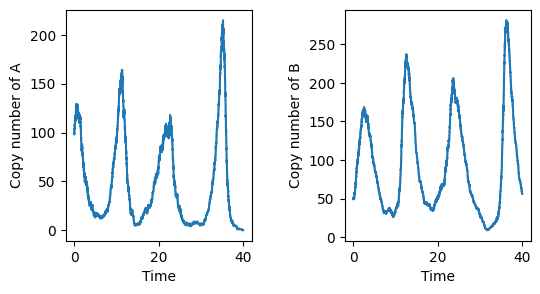

In [11]:
data_dir = "../data"
os.makedirs(data_dir, exist_ok=True)

# Single trajectory at T=20; A0=100 prey, B0=50 predators
time_list, state_list = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=40,
    minVal=[100, 50],
    maxVal=[100, 50],
    seed=42
)

trajectory_file = os.path.join(data_dir, "example4_T40_trajectory.json")
save_trajectory(time_list, state_list, filename=trajectory_file)
print(f"Trajectory saved to {trajectory_file}")
print(f"Total events: {len(time_list)}")


Parsing trajectory...
Tracking 18 unique stoichiometric changes.
Trajectory length: 5805 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 4313 unique states.

4313 unique states observed


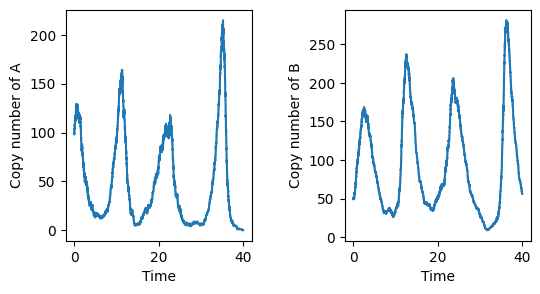

In [12]:
time_list, state_list = load_trajectory("../data/example4_T40_trajectory.json")
reactionNetwork.plot_trajectories(time_list, state_list)

print("Parsing trajectory...")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list, time_list, reactant_matrix, unique_changes, compatible_reactions, verbose=True)

print(f"\n{len(unique_states)} unique states observed")


In [13]:
results_dir = "../results/example4_T40"
os.makedirs(results_dir, exist_ok=True)

runOnlyHigherDim        = False
runOnlyOneHigherDimCase = False

NIterates = 500_000
Burnin    = 50_000
Thinout   = 100

for index, deltaX in enumerate(unique_changes):

    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes,
        index=index, deltaX=deltaX, verbose=True
    )

    localTheta    = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)
    norm_theta    = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    likeTrue    = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    total_count = sum(local_counts.values())
    print(f"True Likelihood = {likeTrue},  Total Count = {total_count}")

    a, b       = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)

    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.75, burn_in=Burnin, adapt_every_n=10,
            printEveryNSteps=1000
        )

        filenameKDE       = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain     = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        summarize_chains([AdaptiveThetaChain], localTheta, ["Adaptive Spike & Slab"],
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break
    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")



Processing Index: 0, Stoichiometric Change: (1, 0)
Extracting local data for stoichiometric change [1, 0] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 4313 states processed.
Local True Theta: [0. 1. 0.] (Norm: 1.0000)
True Likelihood = 6442.409587923203,  Total Count = 1933
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['Empty_to_A:', 'A_to_2A:', 'B_to_A+B:']
Iteration 1000: Accept Rate = 0.204, Theta = [0.         0.98385366 0.        ]
Iteration 2000: Accept Rate = 0.204, Theta = [0.         1.03965167 0.        ]
Iteration 3000: Accept Rate = 0.200, Theta = [0.         0.99398015 0.        ]
Iteration 4000: Accept Rate = 0.197, Theta = [0.         1.02786411 0.        ]
Iteration 5000: Accept Rate = 0.200, Theta = [0.       1.044022 0.      ]
Iteration 6000: Accept Rate = 0.198, Theta = [0.         0.99429055 0.        ]
Iteration 7000: A

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Run 0 | Adaptive Spike & Slab: L2 error of mean from true theta = 0.00511
Saving summary to: ../results/example4_T40/mcmc_summary.xlsx
Summary saved successfully.
MCMC completed for index 0.
**********

Processing Index: 1, Stoichiometric Change: (0, 1)
Extracting local data for stoichiometric change [0, 1] at index 1
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 4313 states processed.
Local True Theta: [0. 0. 0.] (Norm: 0.0000)
True Likelihood = 0,  Total Count = 0
Skipping MCMC for index 1: norm too small (0.0000).
**********

Processing Index: 2, Stoichiometric Change: (2, 0)
Extracting local data for stoichiometric change [2, 0] at index 2
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 4313 states processed.
Local True Theta: [0.] (Norm: 0.0000)
True Likelihood =

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


## LASSO Comparison (sparse-learning-CRN)

Export trajectory data, then run the C++ binaries from a terminal.

In [ ]:
SPARSE_LEARNING_SRC = "/Users/suzanne/Dropbox/WritingProjects/2026_06_08_CRNWork/sparse-learning-CRN/src"
PREPARE_EXE         = os.path.join(SPARSE_LEARNING_SRC, "prepare")
SPARSE_EXE          = os.path.join(SPARSE_LEARNING_SRC, "sparse_learning")

FIXED_LAMBDA = 0.01

lam_str  = str(FIXED_LAMBDA).replace(".", "p")
work_dir = f"../sparse_runs/example4_T40_lam{lam_str}"

export_for_sparse_learning(
    trajectory_files=["../data/example4_T40_trajectory.json"],
    working_dir=work_dir,
    T=40,
    poly_order=2,
    regular_lambda=FIXED_LAMBDA,
    tot_step=20000,
)

print(f"\nExport complete. Now run these commands in a terminal:")
print(f"  cd $(pwd)/{work_dir}")
print(f"  {PREPARE_EXE}")
print(f"  {SPARSE_EXE}")


In [ ]:
# ── Helper functions (2-species version) ────────────────────────────────────
def read_channel_info(run_dir):
    path = os.path.join(run_dir, "output", "channel_info.txt")
    if not os.path.exists(path):
        return None, None
    with open(path) as f:
        lines = [l.strip() for l in f.read().strip().splitlines() if l.strip()]
    n_channels, n_species = map(int, lines[0].split())
    changes = [list(map(int, lines[i+1].split())) for i in range(n_channels)]
    counts  = list(map(int, lines[n_channels+1].split()))
    return changes, counts

def read_omega(run_dir, n_species=2):
    sp     = species_names[:n_species]
    labels = ["1"] + sp + [sp[i]+"*"+sp[j] for i in range(n_species) for j in range(i, n_species)]
    omega  = {}
    for fpath in sorted(glob.glob(os.path.join(run_dir, "output", "omega_vec_for_channel_*.txt"))):
        ch = int(os.path.basename(fpath).split("_")[-1].replace(".txt", ""))
        with open(fpath) as f:
            int(f.readline().strip())
            coeffs = np.array([float(x) for x in f.readline().split()])
        omega[ch] = coeffs
    return omega, labels

# ── True polynomial coefficients for each channel ───────────────────────────
def true_coeff_vector(change, labels):
    """Map true reaction rates → polynomial coefficient vector."""
    c    = np.zeros(len(labels))
    key  = tuple(change)
    if key not in compatible_reactions:
        return c
    reactant_mat_arr = np.array(reactant_matrix)
    for full_idx in compatible_reactions[key]:
        rate = parameter_values.get(CRN_parameter_names[sampled_indices.index(full_idx)], 0.0) \
               if full_idx in sampled_indices else 0.0
        if rate == 0.0:
            continue
        rv = reactant_mat_arr[:, full_idx]
        nz = np.nonzero(rv)[0]
        sp = species_names
        if len(nz) == 0:
            c[labels.index("1")] += rate
        elif len(nz) == 1:
            i, m = nz[0], int(rv[nz[0]])
            if m == 1:
                c[labels.index(sp[i])] += rate
            elif m == 2:
                c[labels.index(sp[i]+"*"+sp[i])] += rate / 2.0
                c[labels.index(sp[i])]            -= rate / 2.0
        elif len(nz) == 2:
            c[labels.index(sp[nz[0]]+"*"+sp[nz[1]])] += rate
    return c

# ── Read and compare results ─────────────────────────────────────────────────
lam_str  = str(FIXED_LAMBDA).replace(".", "p")
work_dir = f"../sparse_runs/example4_T20_lam{lam_str}"

omega, labels = read_omega(work_dir)
ch_changes, ch_counts = read_channel_info(work_dir)

if not omega:
    print("No LASSO results yet — run prepare and sparse_learning from the terminal first.")
else:
    print(f"Polynomial basis ({len(labels)} terms): {labels}")
    print(f"\n{'Ch':>3}  {'Obs':>6}  {'Change':>12}  {'True polynomial':<35}  {'LASSO recovered':<35}  {'L² error':>10}")
    print("-" * 110)

    def poly_str(c, threshold=0.02):
        terms = [f"{v:+.3f}·{labels[i]}" for i, v in enumerate(c) if abs(v) >= threshold]
        return "  ".join(terms) if terms else "0"

    for ch, (change, count) in enumerate(zip(ch_changes, ch_counts)):
        c_true = true_coeff_vector(change, labels)
        c_hat  = omega.get(ch, np.zeros(len(labels)))
        l2_err = np.linalg.norm(c_hat - c_true)
        print(f"{ch:>3}  {count:>6}  {str(change):>12}  {poly_str(c_true):<35}  {poly_str(c_hat):<35}  {l2_err:>10.4f}")
